In [2]:
get_ipython().system('pip install numpy')
get_ipython().system('pip install pandas')
get_ipython().system('pip install seaborn')

In [3]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [5]:
import requests
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = requests.get(URL)
dataset_part_2_csv = io.BytesIO(resp.content)
df = pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


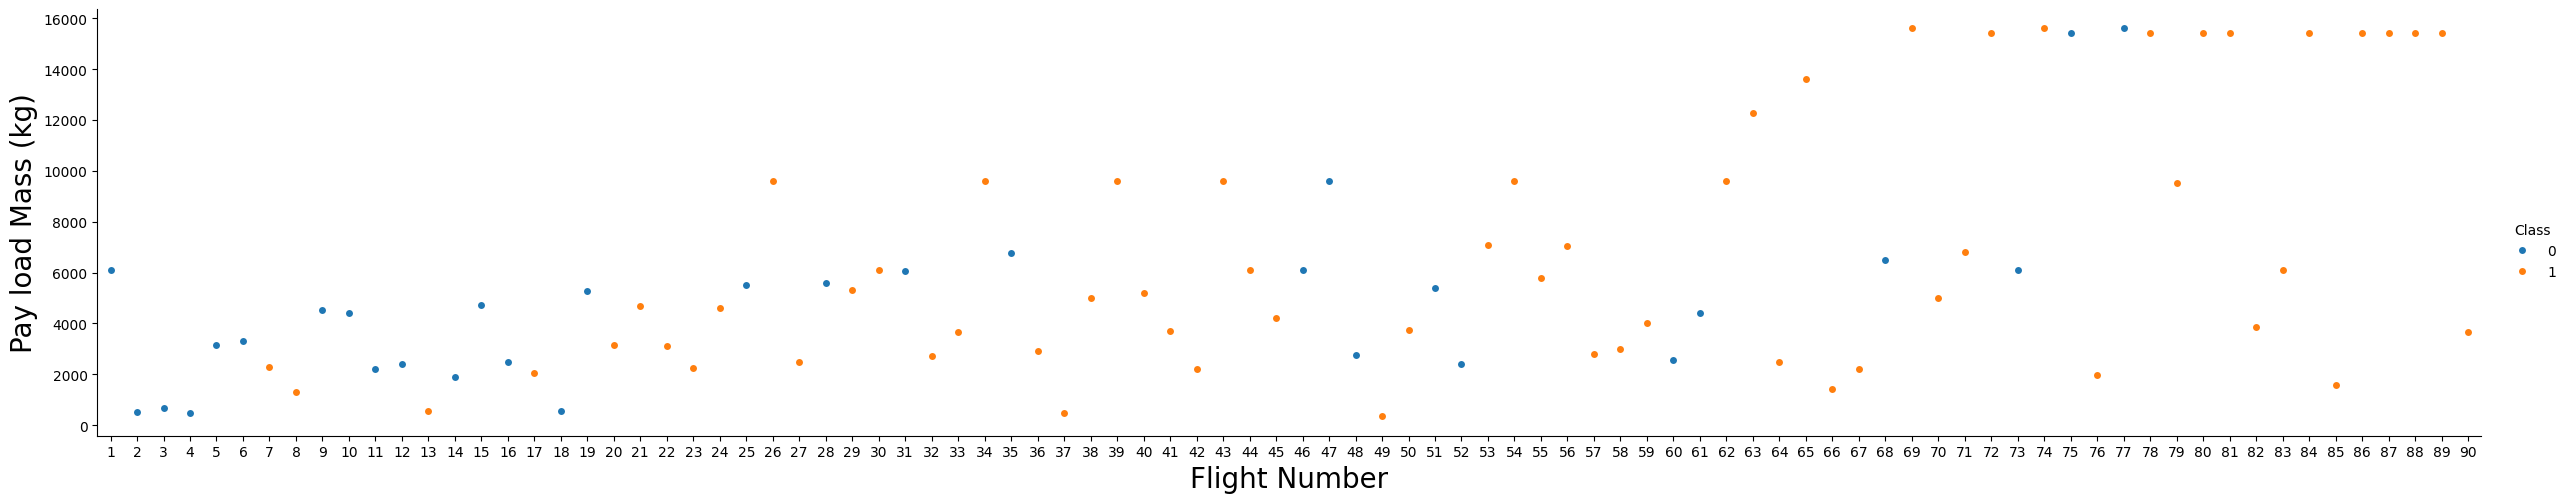

In [6]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

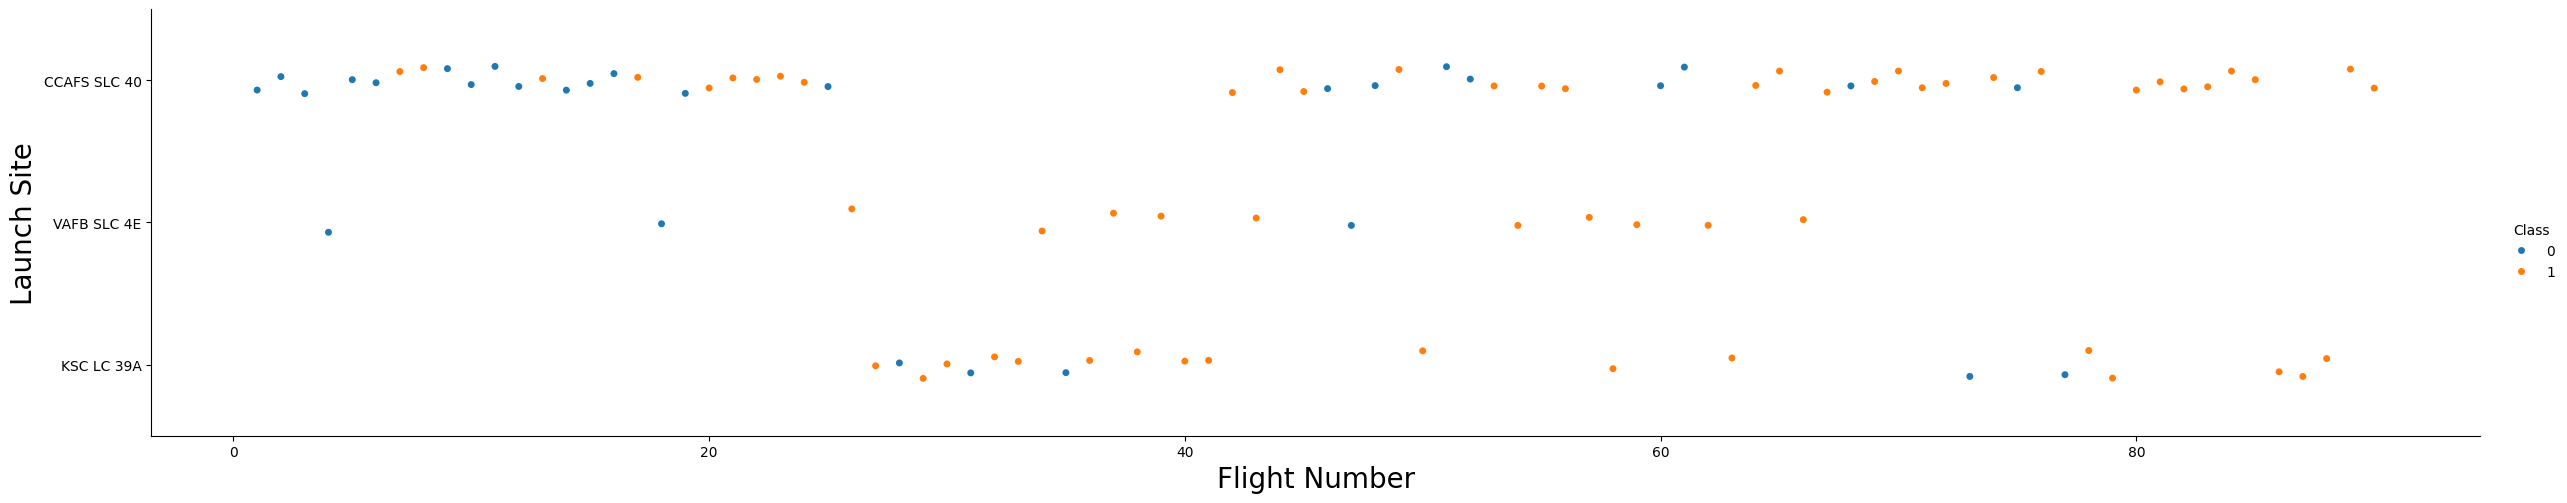

In [7]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

Early Flights and Success Rate: In the initial flights (lower Flight Numbers), the success rate (Class = 1) appears to be lower, with many launches resulting in failure (Class = 0). As Flight Numbers increase, there's a visible trend towards a higher proportion of successful launches.

Launch Site Performance:

CCAFS SLC 40: This launch site shows a mix of successes and failures in earlier flights, but eventually, it achieves a higher success rate over later flights.
VAFB SLC 4E: This site seems to have a generally high success rate, even for its earlier recorded flights compared to other sites.
KSC LC 39A: This site also demonstrates a good success record, especially in its later flights. It appears to have a more consistent success rate once operations are established.
Evolution of Technology/Experience: The overall trend suggests that as SpaceX gained more experience and refined its technology over a greater number of flights, the success rate of their launches improved significantly across all active launch sites.

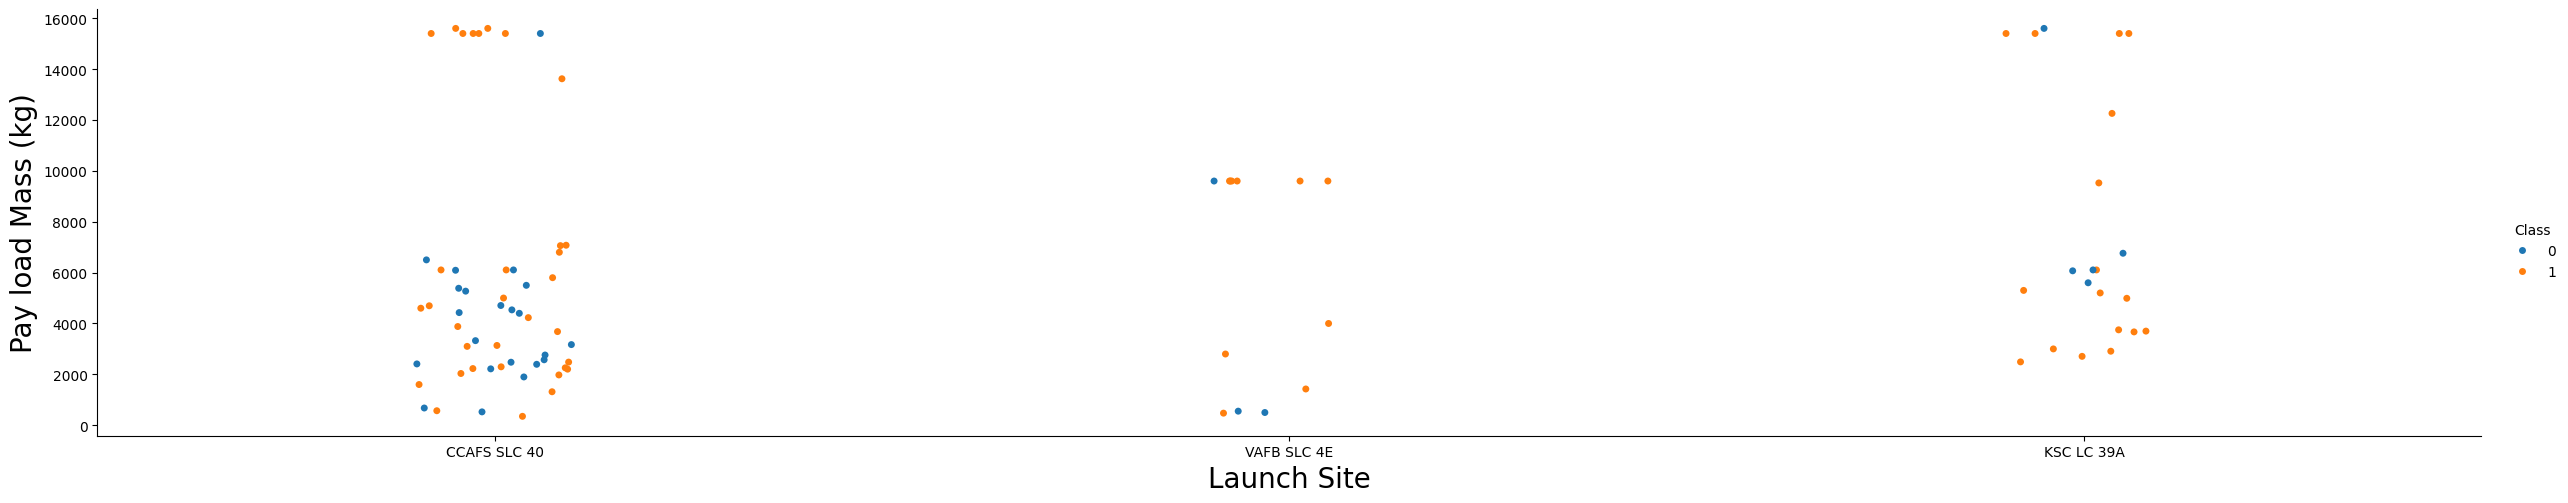

In [8]:
sns.catplot(y="PayloadMass", x="LaunchSite", hue="Class", data=df, aspect = 5)
plt.xlabel("Launch Site",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

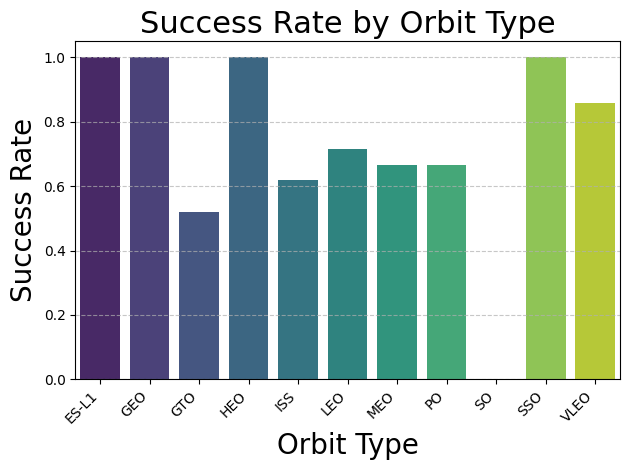

In [10]:
success_rate_by_orbit = df.groupby('Orbit')['Class'].mean().reset_index()

sns.barplot(x='Orbit', y='Class', hue='Orbit', data=success_rate_by_orbit, palette='viridis', legend=False)
plt.xlabel("Orbit Type", fontsize=20)
plt.ylabel("Success Rate", fontsize=20)
plt.title("Success Rate by Orbit Type", fontsize=22)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analysis of Success Rate by Orbit Type

The bar chart illustrates the success rate for different orbit types. Here's what we can observe:

*   **Highest Success Rates (100%):** Orbits such as **ES-L1, GEO, HEO, and SSO** show a perfect 1.0 (100%) success rate. This indicates that all missions to these specific orbits in our dataset were successful.
*   **Very High Success Rates:** **VLEO** (Very Low Earth Orbit) also exhibits a very high success rate of approximately 85.7%.
*   **Good Success Rates:** **LEO** (Low Earth Orbit) has a success rate of about 71.4%, while **MEO** (Medium Earth Orbit) and **PO** (Polar Orbit) are around 66.7%. **ISS** (International Space Station) missions have a success rate of approximately 61.9%.
*   **Moderate Success Rates:** **GTO** (Geosynchronous Transfer Orbit) has a success rate of about 51.9%, indicating a more challenging orbit with a higher proportion of failures compared to others.
*   **Lowest Success Rate:** **SO** (Sun-synchronous Orbit) shows a 0% success rate in this dataset, suggesting all attempts to this orbit were unsuccessful or that there are very few data points for this orbit type that all resulted in failure.

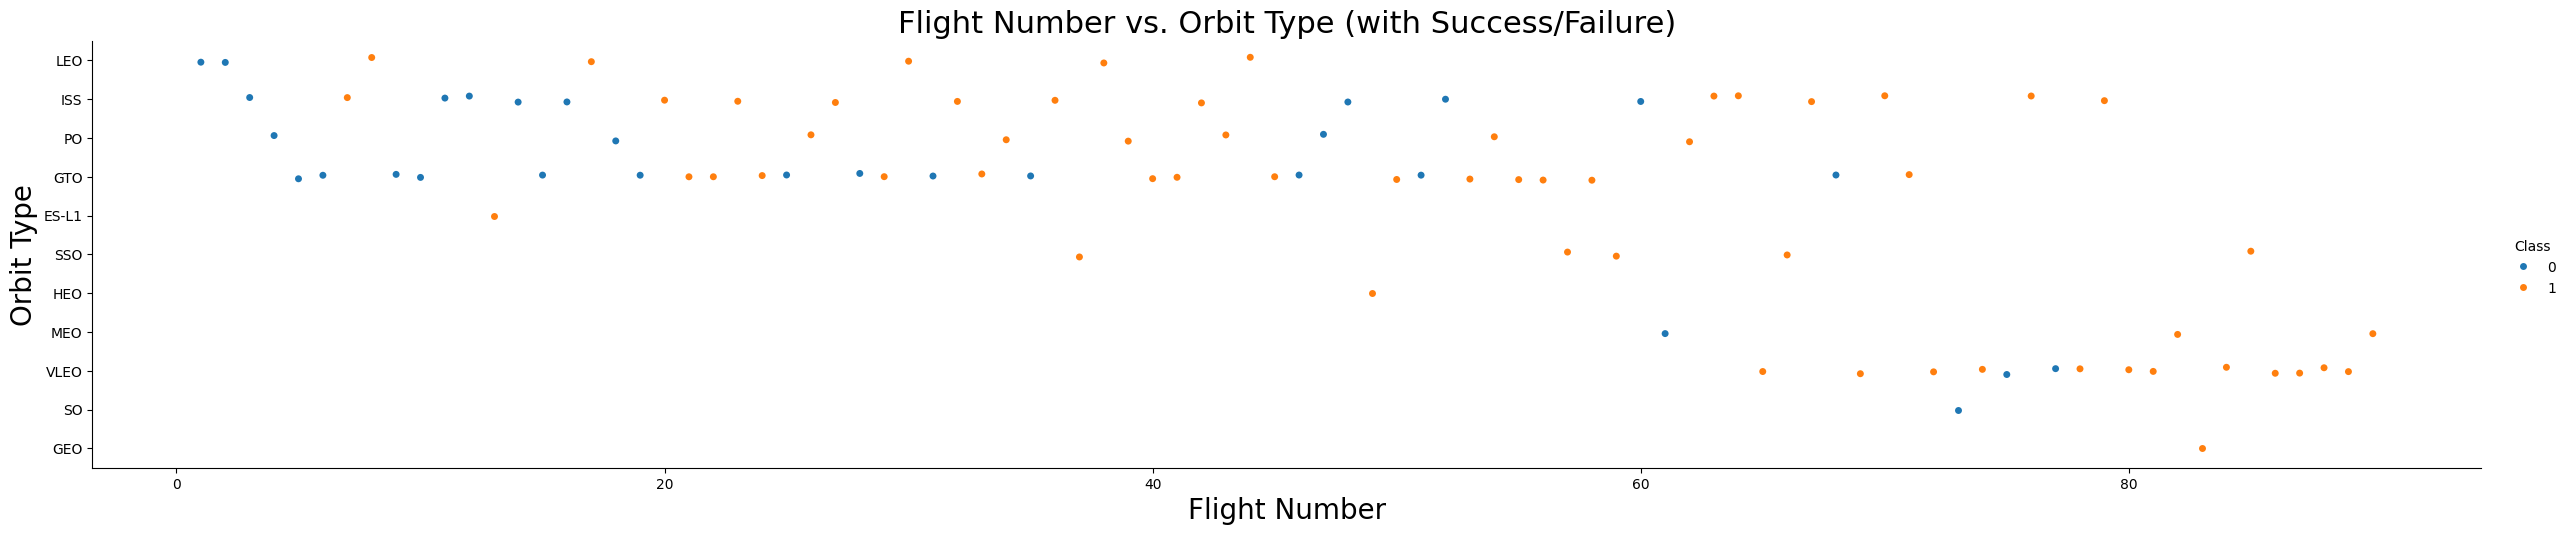

In [11]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Orbit Type",fontsize=20)
plt.title("Flight Number vs. Orbit Type (with Success/Failure)", fontsize=22)
plt.show()

## Analysis of Flight Number vs. Orbit Type (with Success/Failure)

This plot helps us understand how the success rate of missions to different orbit types has evolved over the `FlightNumber` sequence.

*   **Early Flights (Lower Flight Numbers):**
    *   Many of the very early flights (FlightNumber < 20) were targeted at **LEO** and **ISS** orbits. These early attempts show a mix of successes (green dots) and failures (red dots), indicating the initial challenges in achieving consistent success.
    *   There's a notable concentration of early failures in LEO and ISS orbits, suggesting a learning curve in the early stages of the program.

*   **Evolution to Other Orbits:**
    *   As `FlightNumber` increases, missions start to diversify into other orbit types such as **GTO**, **PO**, **SSO**, and **MEO**.
    *   For **GTO** (Geosynchronous Transfer Orbit), failures are observed across a wider range of flight numbers, even up to higher flight numbers, which aligns with GTO being a more challenging orbit.

*   **Improved Success Over Time:**
    *   For most orbit types, especially **LEO** and **ISS**, there is a clear trend: as `FlightNumber` increases, the proportion of successful missions (green dots) significantly rises. This indicates improved reliability and experience over time.
    *   Orbits like **ES-L1, GEO, HEO, and VLEO** appear to have a higher success rate, with missions to these orbits generally being successful, particularly in later flight numbers.

*   **Specific Orbit Observations:**
    *   **LEO and ISS:** These orbits have a long history of missions, showing the most significant evolution from initial failures to consistent successes.
    *   **GTO:** Continues to show some failures even in later flights, suggesting its inherent difficulty.
    *   **PO and SSO:** Tend to have a good success record once missions to these orbits begin, often with fewer early failures compared to LEO/ISS.
    *   **VLEO, ES-L1, GEO, HEO:** These orbits generally appear with higher success rates throughout their respective flight numbers in the dataset.

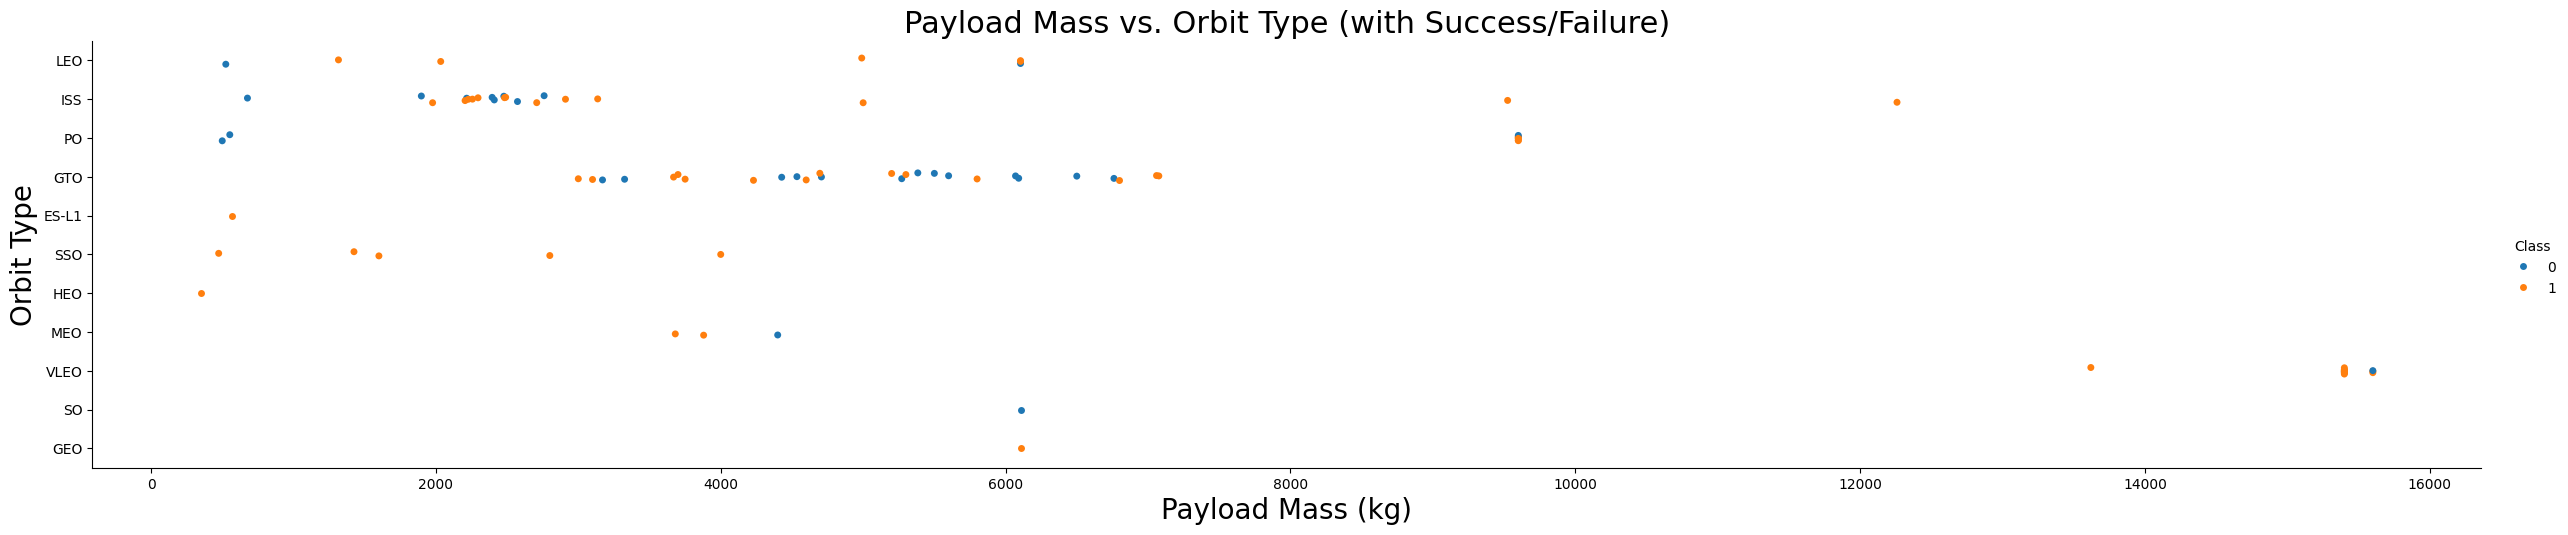

In [13]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Payload Mass (kg)",fontsize=20)
plt.ylabel("Orbit Type",fontsize=20)
plt.title("Payload Mass vs. Orbit Type (with Success/Failure)", fontsize=22)
plt.show()

## Analysis of Payload Mass vs. Orbit Type (with Success/Failure)

This plot helps us visualize the distribution of payload masses for different orbit types and how it correlates with mission success.

*   **Payload Mass Range per Orbit:**
    *   **LEO (Low Earth Orbit):** Shows a wide range of payload masses, from very light to heavy (e.g., up to ~15,000 kg). Both successful (green) and unsuccessful (red) launches are distributed across this range, with a tendency for higher success with larger payloads in later missions.
    *   **ISS (International Space Station):** Missions to the ISS also cover a significant range of payload masses, typically medium to heavy. Success rates appear generally high for these missions, especially for heavier payloads.
    *   **GTO (Geosynchronous Transfer Orbit):** Primarily handles medium to heavy payloads, often clustering around specific mass points. This orbit shows a mix of successes and failures across its payload range, suggesting the challenges associated with reaching GTO.
    *   **VLEO (Very Low Earth Orbit):** Appears to handle lighter to medium payloads, with a high success rate for these missions.
    *   **MEO (Medium Earth Orbit), PO (Polar Orbit), SSO (Sun-synchronous Orbit):** These orbits also accommodate various payload masses, generally medium-sized, and show relatively high success rates.
    *   **ES-L1, GEO, HEO:** These orbits typically handle specific, often lighter to medium payloads, and all launches to these orbits in our dataset have been successful.

*   **Success and Failure Patterns:**
    *   For orbits like **LEO** and **ISS**, successes are observed across nearly the entire payload mass spectrum, though some early failures are present for various masses.
    *   **GTO** shows a more pronounced presence of failures, distributed among different payload masses, indicating that reaching this orbit successfully remains a challenge for a range of payload sizes.
    *   Generally, for many orbits, there's a trend where heavier, more complex payloads tend to have higher success rates, possibly due to more robust rockets and technologies being used for such valuable missions, or simply reflecting the later, more mature phase of the launch program.

*   **Payload Mass Concentration:** Some orbits show concentrations of specific payload masses, reflecting mission requirements. For instance, specific communication or scientific satellites might consistently target certain orbits with similar payload weights.

In [14]:
# A function to Extract years from the date
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


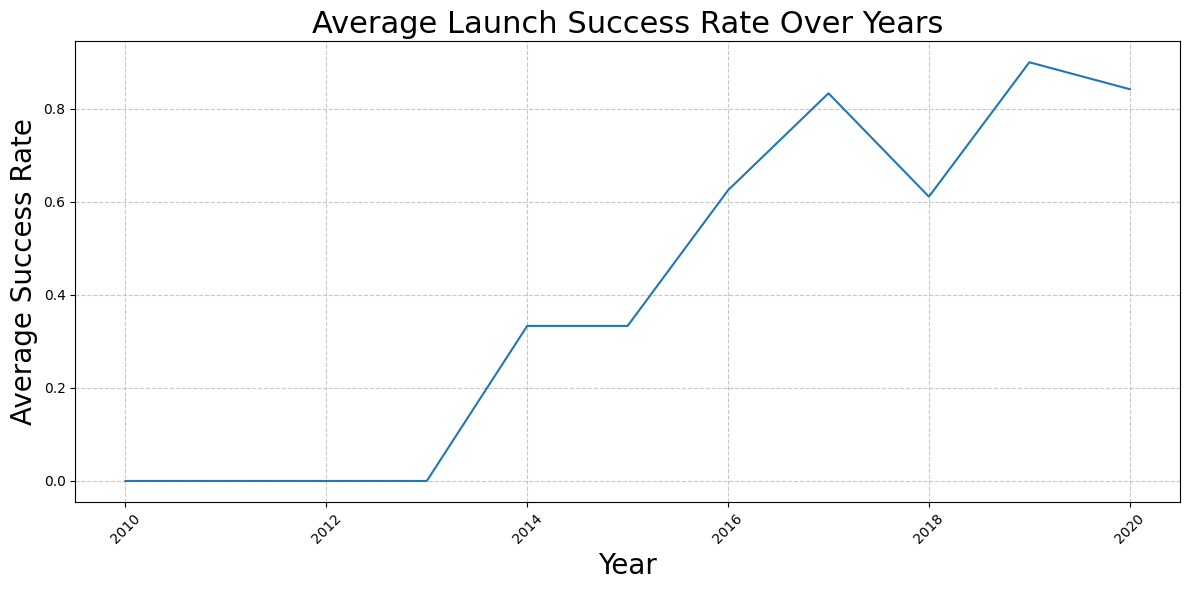

In [15]:
# Convert 'Date' column to numeric for proper plotting (it now contains years as strings)
df['Date'] = pd.to_numeric(df['Date'])

# Calculate average success rate per year
success_rate_by_year = df.groupby('Date')['Class'].mean().reset_index()

# Plotting the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Class', data=success_rate_by_year)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Average Success Rate", fontsize=20)
plt.title("Average Launch Success Rate Over Years", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analysis of Average Launch Success Rate Over Years

This line chart displays the average success rate of rocket launches from 2010 to 2020. We can observe the following trends:

*   **Early Years (2010-2013):** The success rate in the very early years (2010, 2012, 2013) appears to be 0% in this dataset, indicating either no successful launches or very few attempts, all of which failed during this period. This is typical for the nascent stages of any complex launch program as technologies are tested and refined.

*   **Gradual Improvement (2014-2016):** Starting from 2014, there's a visible, albeit slow, increase in the average success rate. It rises from around 33% in 2014-2015 to approximately 62.5% in 2016. This period likely reflects ongoing development, learning from failures, and iterative improvements in launch vehicles and operations.

*   **Significant Growth (2017):** The year 2017 shows a remarkable jump in success rate, reaching about 83.3%. This indicates a period of maturation for the launch program, where the reliability significantly improved, possibly due to refined procedures, more experienced teams, and more robust hardware.

*   **Fluctuations and High Success (2018-2020):** After 2017, the success rate generally remains high, though with some fluctuations. It slightly dips in 2018 to around 61.1% but then rebounds strongly in 2019 to about 90%. In 2020, it remains high at approximately 84.2%. These later years demonstrate a sustained period of high success, suggesting that the launch capabilities have become consistently reliable.

**Overall Trend:** The overall trend clearly shows a positive progression from low success rates in the initial years to consistently high success rates in recent years, highlighting the continuous improvement and technological advancements in space launch operations over the decade.

In [16]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### One-Hot Encoding Categorical Features

I will now apply one-hot encoding to the categorical features 'Orbit', 'LaunchSite', 'LandingPad', and 'Serial' using `pd.get_dummies()`. This process converts categorical variables into a format that can be provided to machine learning algorithms to improve prediction accuracy.

In [17]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], drop_first=False)
display(features_one_hot.head())

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### Type Conversion to `float64`

Now that all categorical features have been one-hot encoded and the DataFrame `features_one_hot` contains only numerical values (boolean or numeric), I will convert the entire DataFrame to the `float64` data type. This ensures consistency and compatibility for machine learning models.

In [18]:
features_one_hot = features_one_hot.astype(float)
display(features_one_hot.head())

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)